# Modelos fundacionais para dados tabulares — TabICL

Modelos fundacionais tabulares sao transformers **pre-treinados em milhoes de datasets sinteticos**. Em vez de treinar do zero no seu problema, eles fazem *in-context learning*: o `.fit()` nao ajusta pesos por gradiente, ele apenas guarda os seus dados de treino para usar como **contexto**. A previsao sai de um unico forward pass condicionado nesse contexto, **sem tuning de hiperparametros**.

Usamos o **TabICL**, um modelo fundacional para regressao tabular. Alem da media, ele devolve **quantis** da distribuicao preditiva, ou seja, uma faixa de incerteza de graca.

O notebook tem dois experimentos:

1. **Incerteza**: a faixa nativa do TabICL (pelos quantis) **vs** uma RandomForest com **conformal prediction normalizado**.
2. **Acuracia sem tuning**: num dataset pequeno, o TabICL *sem tunar nada* **vs** modelos classicos com hiperparametros **escolhidos na calibracao**.

> Existe outro modelo fundacional tabular famoso, o **TabPFN**, mas ele exige aceitar uma licenca e um token para inferencia local, entao aqui ficamos so com o TabICL.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.datasets import load_diabetes

from tabicl import TabICLRegressor

# cobertura alvo de 90%
alpha = 0.10

/home/thiago/disciplinas/2026/cd/ciencia_dados/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parte 1 — Faixa de incerteza

## Dataset sintetico

O ruido **depende de `x`**: perto de `x = 0` os pontos sao quase certos, e nas pontas a dispersao cresce. Esse e o caso interessante, porque uma faixa de largura fixa nao serve: queremos faixa estreita no meio e larga nas bordas.


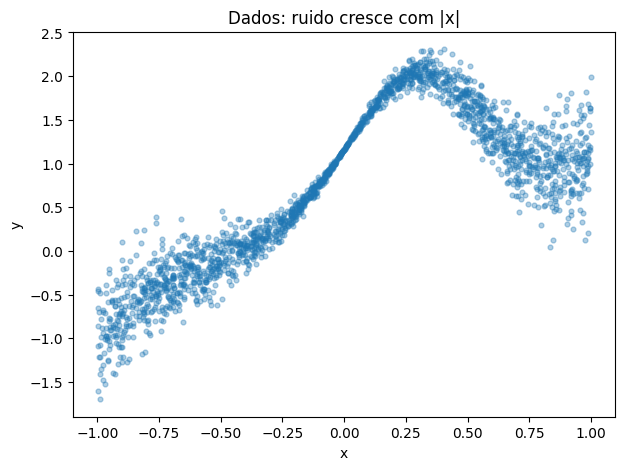

In [2]:
rng = np.random.default_rng(42)

n = 2000
x = rng.uniform(-1, 1, size=n)
y = x**3 + 2 * np.exp(-6 * (x - 0.3)**2)
y = y + rng.normal(scale=0.35 * np.abs(x), size=n)

X = x.reshape(-1, 1)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=12, alpha=0.35)
plt.title("Dados: ruido cresce com |x|")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Separando os dados

- **treino**: ajusta a RandomForest e vira o contexto do TabICL.
- **calibracao**: onde o conformal escolhe o quantil que garante a cobertura.
- **teste**: onde avaliamos as faixas no final.


In [3]:
X_treino_cal, X_teste, y_treino_cal, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_treino, X_cal, y_treino, y_cal = train_test_split(
    X_treino_cal, y_treino_cal, test_size=0.25, random_state=42
)

print("treino:    ", X_treino.shape)
print("calibracao:", X_cal.shape)
print("teste:     ", X_teste.shape)

treino:     (1200, 1)
calibracao: (400, 1)
teste:      (400, 1)


## TabICL: faixa nativa pelos quantis

Treinamos o TabICL (que so guarda o contexto) e pedimos, para cada ponto de teste, a media e os quantis de 5%, 50% e 95%. A faixa entre o quantil 5% e o 95% e uma regiao de 90% direto do modelo, **sem calibracao**.


In [4]:
reg = TabICLRegressor()
reg.fit(X_treino, y_treino)

saida = reg.predict(
    X_teste, output_type=["mean", "quantiles"], alphas=[0.05, 0.5, 0.95]
)

pred_tabicl = saida["mean"]
baixo_nativo = saida["quantiles"][:, 0]   # quantil 5%
alto_nativo = saida["quantiles"][:, 2]    # quantil 95%

cobertura_nativa = ((y_teste >= baixo_nativo) & (y_teste <= alto_nativo)).mean()
largura_nativa = np.mean(alto_nativo - baixo_nativo)

pd.Series({
    "cobertura": cobertura_nativa,
    "largura_media": largura_nativa,
    "mae": mean_absolute_error(y_teste, pred_tabicl),
})

cobertura        0.907500
largura_media    0.598486
mae              0.138557
dtype: float64

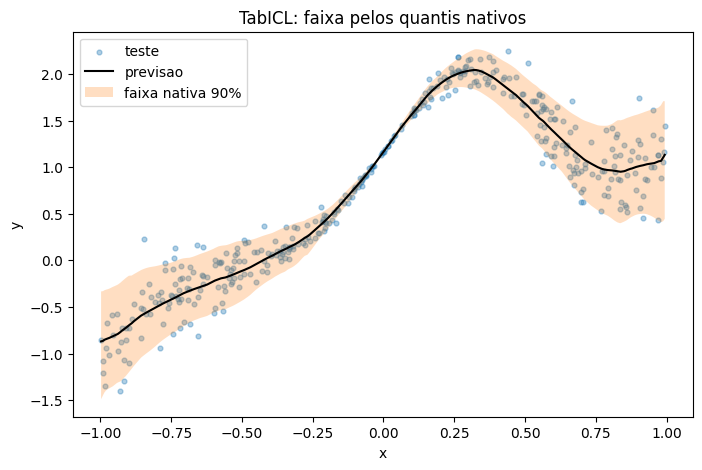

In [5]:
ordem = np.argsort(X_teste[:, 0])
x_plot = X_teste[ordem, 0]

plt.figure(figsize=(8, 5))
plt.scatter(x_plot, y_teste[ordem], s=12, alpha=0.35, label="teste")
plt.plot(x_plot, pred_tabicl[ordem], color="black", label="previsao")
plt.fill_between(
    x_plot, baixo_nativo[ordem], alto_nativo[ordem], alpha=0.25, label="faixa nativa 90%"
)
plt.title("TabICL: faixa pelos quantis nativos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## RandomForest + conformal normalizado

A faixa nativa do TabICL nao tem garantia formal de cobertura. O conformal prediction da essa garantia para um modelo qualquer; aqui o modelo base e uma RandomForest. Na versao **normalizada** a largura muda de ponto para ponto:

1. Treinamos a RandomForest e, com os residuos dela no treino, treinamos um `modelo_variancia` para prever o tamanho do erro (`residuo**2`).
2. Na **calibracao** medimos o score normalizado `|y - previsao| / escala`, com `escala = sqrt(variancia prevista)`.
3. O corte `q` e um quantil desses scores (com correcao de amostra finita).
4. No teste, a faixa fica `previsao +- q * escala`.


In [6]:
modelo = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=20, n_jobs=-1, random_state=42
)
modelo.fit(X_treino, y_treino)

# modelo de variancia treinado nos residuos do proprio treino
residuos = y_treino - modelo.predict(X_treino)
modelo_variancia = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=20, n_jobs=-1, random_state=42
)
modelo_variancia.fit(X_treino, residuos**2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [7]:
# scores normalizados na calibracao
pred_cal = modelo.predict(X_cal)
escala_cal = np.sqrt(np.maximum(modelo_variancia.predict(X_cal), 1e-6))
scores_cal = np.abs(y_cal - pred_cal) / escala_cal

n_cal = len(scores_cal)
nivel_quantil = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q = np.quantile(scores_cal, nivel_quantil, method="higher")

# faixa adaptativa no teste
pred_rf = modelo.predict(X_teste)
escala_teste = np.sqrt(np.maximum(modelo_variancia.predict(X_teste), 1e-6))
baixo_conf = pred_rf - q * escala_teste
alto_conf = pred_rf + q * escala_teste

cobertura_conf = ((y_teste >= baixo_conf) & (y_teste <= alto_conf)).mean()
largura_conf = np.mean(alto_conf - baixo_conf)

pd.Series({
    "cobertura": cobertura_conf,
    "largura_media": largura_conf,
    "mae": mean_absolute_error(y_teste, pred_rf),
})

cobertura        0.917500
largura_media    0.650534
mae              0.144775
dtype: float64

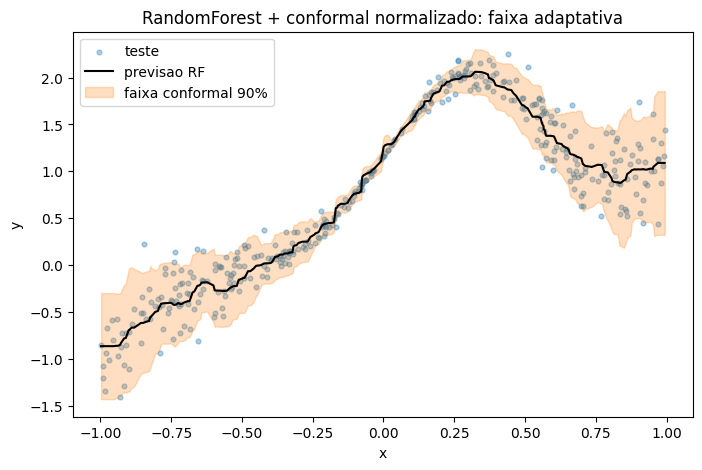

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(x_plot, y_teste[ordem], s=12, alpha=0.35, label="teste")
plt.plot(x_plot, pred_rf[ordem], color="black", label="previsao RF")
plt.fill_between(
    x_plot, baixo_conf[ordem], alto_conf[ordem], alpha=0.25,
    color="tab:orange", label="faixa conformal 90%"
)
plt.title("RandomForest + conformal normalizado: faixa adaptativa")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Comparando as duas faixas

As duas miram 90% de cobertura. A do TabICL sai de graca dos quantis; a da RandomForest precisa de um conjunto de calibracao, mas vem com garantia distribution-free.


In [9]:
comparacao_incerteza = pd.DataFrame({
    "metodo": ["TabICL quantis nativos", "RandomForest + conformal"],
    "cobertura": [cobertura_nativa, cobertura_conf],
    "largura_media": [largura_nativa, largura_conf],
})
comparacao_incerteza

,metodo,cobertura,largura_media
0,TabICL quantis nativos,0.9075,0.598486
1,RandomForest + conformal,0.9175,0.650534


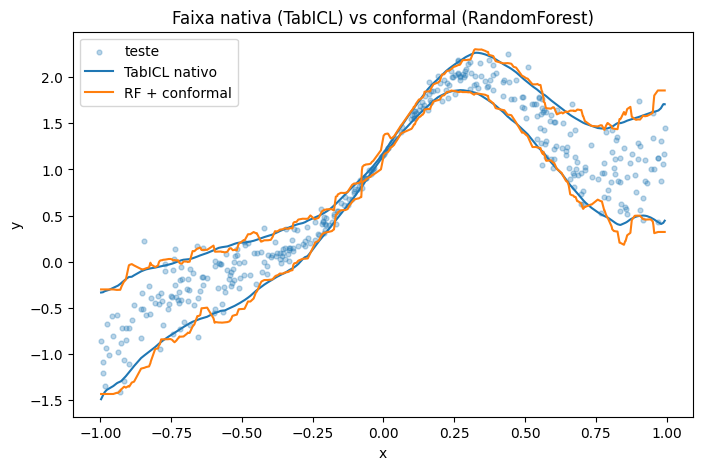

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(x_plot, y_teste[ordem], s=12, alpha=0.30, label="teste")
plt.plot(x_plot, baixo_nativo[ordem], color="tab:blue", linewidth=1.5, label="TabICL nativo")
plt.plot(x_plot, alto_nativo[ordem], color="tab:blue", linewidth=1.5)
plt.plot(x_plot, baixo_conf[ordem], color="tab:orange", linewidth=1.5, label="RF + conformal")
plt.plot(x_plot, alto_conf[ordem], color="tab:orange", linewidth=1.5)
plt.title("Faixa nativa (TabICL) vs conformal (RandomForest)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Parte 2 — Acuracia sem tuning

A outra promessa de um modelo fundacional e competir **sem tuning**. Aqui comparamos, num dataset pequeno real (`diabetes`, 442 pacientes, 10 variaveis), o TabICL *out-of-the-box* contra modelos classicos cujos hiperparametros sao **escolhidos na calibracao**.


In [11]:
Xd, yd = load_diabetes(return_X_y=True)

Xd_treino, Xd_teste, yd_treino, yd_teste = train_test_split(
    Xd, yd, test_size=0.20, random_state=0
)
Xd_treino, Xd_cal, yd_treino, yd_cal = train_test_split(
    Xd_treino, yd_treino, test_size=0.25, random_state=0
)

print("treino:    ", Xd_treino.shape)
print("calibracao:", Xd_cal.shape)
print("teste:     ", Xd_teste.shape)

treino:     (264, 10)
calibracao: (89, 10)
teste:      (89, 10)


## TabICL sem tunar

So `fit` e `predict`. Damos ao TabICL os dados de treino e calibracao juntos como contexto (a mesma informacao que os modelos tunados acabam usando) e nenhum hiperparametro e ajustado.


In [12]:
Xd_trcal = np.vstack([Xd_treino, Xd_cal])
yd_trcal = np.concatenate([yd_treino, yd_cal])

reg_d = TabICLRegressor()
reg_d.fit(Xd_trcal, yd_trcal)
pred_d_tabicl = reg_d.predict(Xd_teste, output_type="mean")

mae_tabicl = mean_absolute_error(yd_teste, pred_d_tabicl)
r2_tabicl = r2_score(yd_teste, pred_d_tabicl)
print("TabICL  MAE:", round(mae_tabicl, 2), " R2:", round(r2_tabicl, 3))

TabICL  MAE: 44.19  R2: 0.352


## Modelos classicos com tuning na calibracao

Para os competidores, fazemos busca em grade de hiperparametros usando **a calibracao como conjunto de validacao**. O `PredefinedSplit` diz ao `GridSearchCV` para treinar so no treino (`-1`) e validar so na calibracao (`0`). No fim, o melhor modelo e re-treinado em treino + calibracao e avaliado no teste — a mesma base que o TabICL recebeu.


In [13]:
# -1 = sempre treino, 0 = conjunto de validacao (calibracao)
test_fold = np.r_[np.full(len(Xd_treino), -1), np.zeros(len(Xd_cal))]
ps = PredefinedSplit(test_fold)

candidatos = {
    "RandomForest": (
        RandomForestRegressor(random_state=0, n_jobs=-1),
        {"n_estimators": [100, 300], "max_depth": [None, 5, 10],
         "min_samples_leaf": [1, 5]},
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=0),
        {"n_estimators": [100, 300], "max_depth": [2, 3],
         "learning_rate": [0.05, 0.1]},
    ),
    "Ridge": (
        Ridge(),
        {"alpha": [0.1, 1.0, 10.0, 100.0]},
    ),
}

linhas = [{"modelo": "TabICL (sem tuning)", "mae": mae_tabicl, "r2": r2_tabicl}]

for nome, (estimador, grade) in candidatos.items():
    busca = GridSearchCV(
        estimador, grade, scoring="neg_mean_absolute_error", cv=ps
    )
    busca.fit(Xd_trcal, yd_trcal)
    pred = busca.predict(Xd_teste)
    linhas.append({
        "modelo": nome + " (tunado)",
        "mae": mean_absolute_error(yd_teste, pred),
        "r2": r2_score(yd_teste, pred),
    })

resultados = pd.DataFrame(linhas).sort_values("mae").reset_index(drop=True)
resultados.round(3)

,modelo,mae,r2
0,TabICL (sem tuning),44.186,0.352
1,GradientBoosting (tunado),45.680,0.326
2,Ridge (tunado),45.688,0.342
3,RandomForest (tunado),46.801,0.290


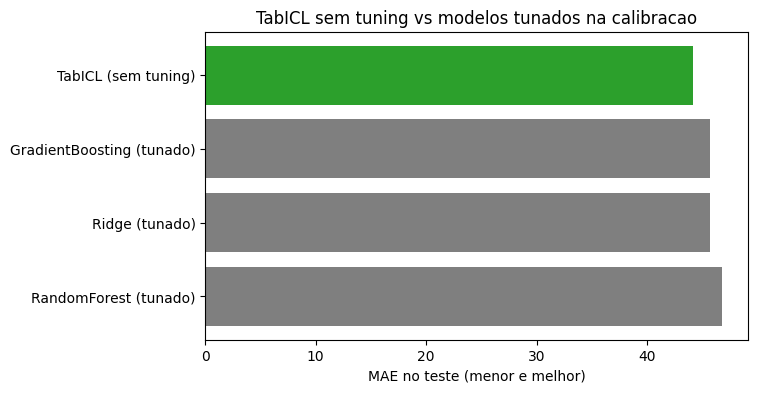

In [14]:
plt.figure(figsize=(7, 4))
cores = ["tab:green" if "TabICL" in m else "tab:gray" for m in resultados["modelo"]]
plt.barh(resultados["modelo"], resultados["mae"], color=cores)
plt.gca().invert_yaxis()
plt.xlabel("MAE no teste (menor e melhor)")
plt.title("TabICL sem tuning vs modelos tunados na calibracao")
plt.show()

## Conclusao

- **Incerteza**: o TabICL ja entrega uma faixa pelos quantis, sem treino extra nem calibracao, mas sem garantia formal. A RandomForest com conformal normalizado custa um conjunto de calibracao e, em troca, garante cobertura marginal com largura adaptativa. Os dois se completam.
- **Acuracia**: sem tunar nenhum hiperparametro, o TabICL fica **competitivo** com modelos classicos que gastaram a calibracao em busca de hiperparametros. Esse e o apelo pratico do modelo fundacional: bom desempenho com esforco quase zero.

> O mesmo pipeline vale para outros datasets tabulares. Lembre que o custo do TabICL cresce com o tamanho do contexto, entao para bases muito grandes vale subamostrar o treino.
